In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet
print("Libraries ready!")

Libraries ready!


In [2]:
import pandas as pd
df = pd.read_csv('cleaned_jobs.csv')
print("Columns:", df.columns.tolist())
print("\nShape:", df.shape)
print("\nFirst row:")
print(df.iloc[0])

Columns: ['job_title', 'role_category', 'job_level', 'company', 'job_location', 'job_skills', 'skill_count']

Shape: (29254, 7)

First row:
job_title                 Senior Network Engineering Lead - Remote
role_category                                     Network Engineer
job_level                                                   Senior
company                                         Ryder System, Inc.
job_location                                          Richmond, VA
job_skills       azure, amazon web services (aws), network plan...
skill_count                                                     49
Name: 0, dtype: object


In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Load the dataset
df = pd.read_csv('cleaned_jobs.csv')
df = df.dropna(subset=['job_skills', 'role_category'])

# Load saved models
tfidf = joblib.load('tfidf_vectorizer.pkl')
rf_model = joblib.load('rf_career_model.pkl')
label_encoder = joblib.load('label_encoder.pkl')

# Prepare features and labels
X = tfidf.transform(df['job_skills'])
y = label_encoder.transform(df['role_category'])

# Recreate the same 80/20 split used in training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

print("Setup complete!")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Number of role categories: {len(label_encoder.classes_)}")
print(f"Roles: {list(label_encoder.classes_)}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaki

Setup complete!
Test set size: 5851 samples
Number of role categories: 11
Roles: ['Backend Developer', 'Cybersecurity Analyst', 'Data Analyst', 'Data Engineer', 'Data Scientist', 'Database Administrator', 'DevOps Engineer', 'Frontend Developer', 'Network Engineer', 'Software Engineer', 'System Administrator']


In [4]:
# Calculate overall metrics
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("="*50)
print("RANDOM FOREST - CAREER ROLE PREDICTION RESULTS")
print("="*50)
print(f"Accuracy:            {accuracy*100:.2f}%")
print(f"Precision (Macro):   {precision_macro*100:.2f}%")
print(f"Recall (Macro):      {recall_macro*100:.2f}%")
print(f"F1-Score (Macro):    {f1_macro*100:.2f}%")
print(f"Precision (Weighted):{precision_weighted*100:.2f}%")
print(f"Recall (Weighted):   {recall_weighted*100:.2f}%")
print(f"F1-Score (Weighted): {f1_weighted*100:.2f}%")
print("="*50)

RANDOM FOREST - CAREER ROLE PREDICTION RESULTS
Accuracy:            86.48%
Precision (Macro):   88.60%
Recall (Macro):      74.13%
F1-Score (Macro):    78.79%
Precision (Weighted):86.87%
Recall (Weighted):   86.48%
F1-Score (Weighted): 85.90%


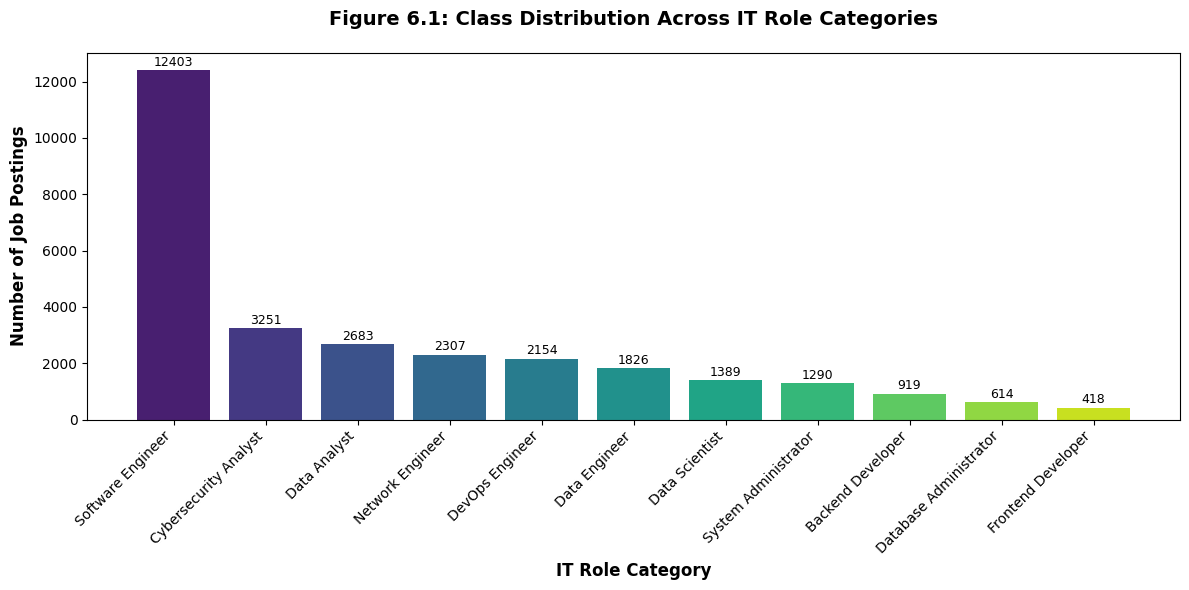

Chart 1 saved!


In [5]:
# Chart 1: Class Distribution
plt.figure(figsize=(12, 6))
role_counts = df['role_category'].value_counts()
colors = sns.color_palette("viridis", len(role_counts))
bars = plt.bar(range(len(role_counts)), role_counts.values, color=colors)
plt.xticks(range(len(role_counts)), role_counts.index, rotation=45, ha='right')
plt.ylabel('Number of Job Postings', fontsize=12, fontweight='bold')
plt.xlabel('IT Role Category', fontsize=12, fontweight='bold')
plt.title('Figure 6.1: Class Distribution Across IT Role Categories',
          fontsize=14, fontweight='bold', pad=20)

# Add count labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('chart1_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

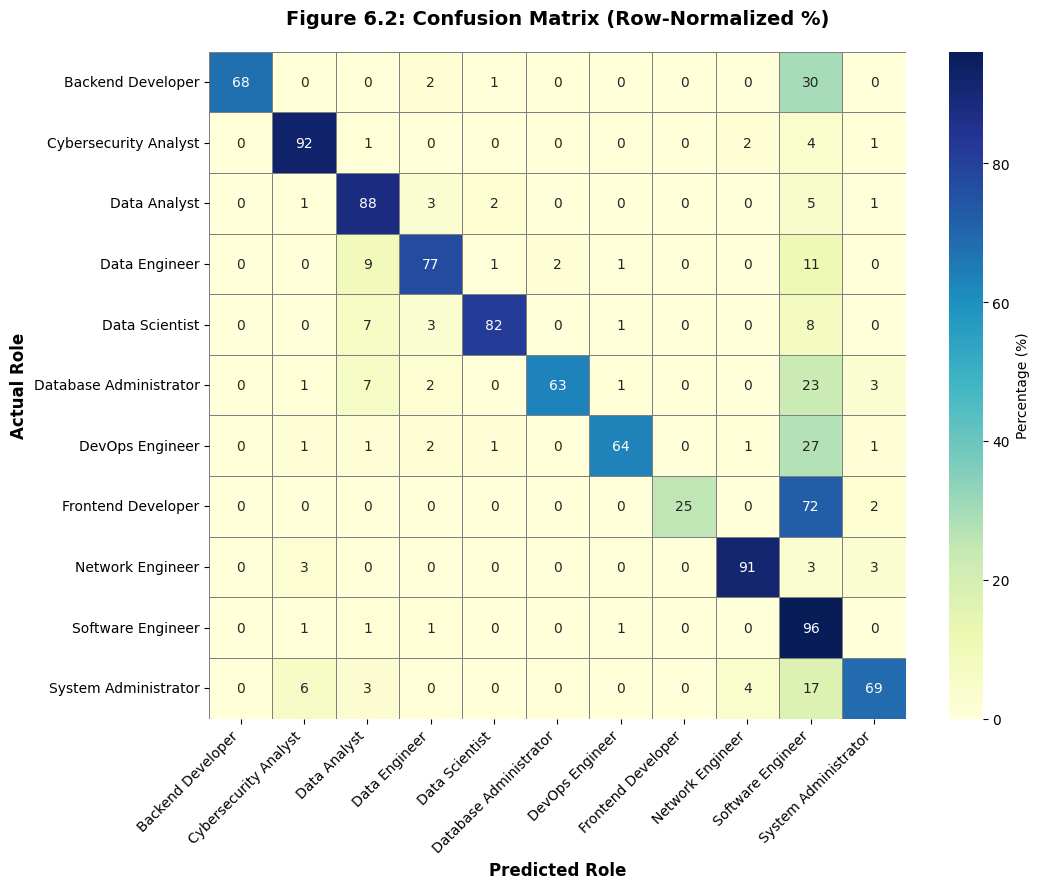

Chart 2 saved!


In [6]:
# Chart 2: Confusion Matrix
plt.figure(figsize=(11, 9))
cm = confusion_matrix(y_test, y_pred)
role_names = label_encoder.classes_

# Normalize to percentages per row (recall view)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm_normalized, annot=True, fmt='.0f', cmap='YlGnBu',
            xticklabels=role_names, yticklabels=role_names,
            cbar_kws={'label': 'Percentage (%)'}, linewidths=0.5, linecolor='gray')
plt.ylabel('Actual Role', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Role', fontsize=12, fontweight='bold')
plt.title('Figure 6.2: Confusion Matrix (Row-Normalized %)',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('chart2_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

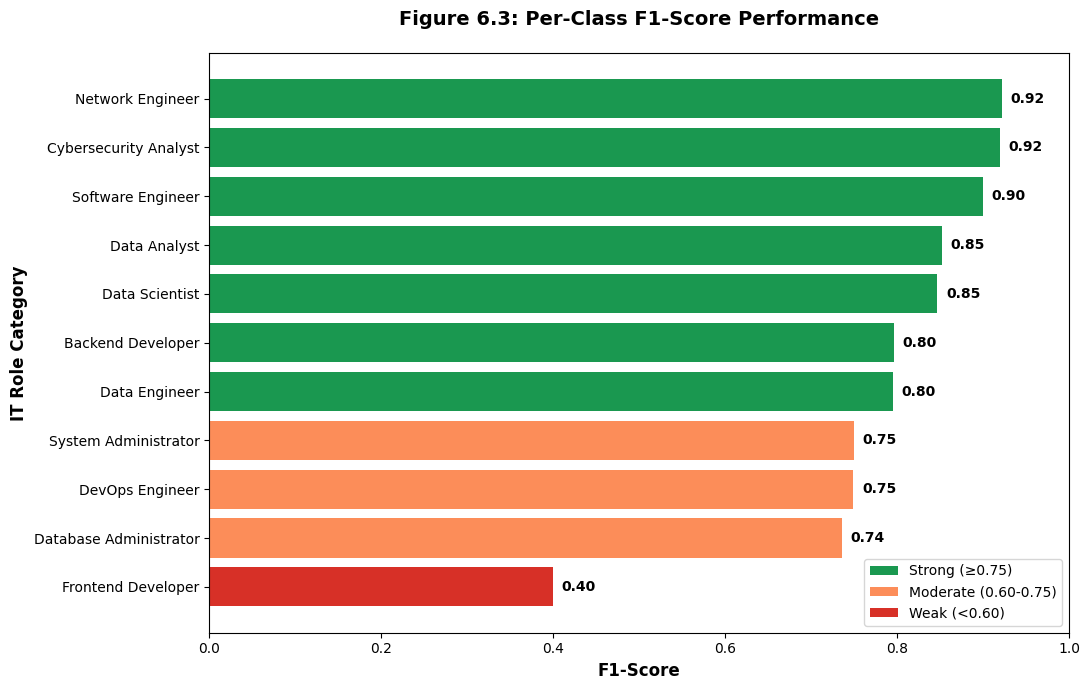

Chart 3 saved!


In [7]:
# Chart 3: Per-Class F1 Score
from sklearn.metrics import f1_score as f1_per_class

f1_scores = f1_per_class(y_test, y_pred, average=None, zero_division=0)
role_names = label_encoder.classes_

# Sort by F1 score for better visualization
sorted_idx = np.argsort(f1_scores)
sorted_f1 = f1_scores[sorted_idx]
sorted_names = role_names[sorted_idx]

plt.figure(figsize=(11, 7))
colors = ['#d73027' if score < 0.6 else '#fc8d59' if score < 0.75 else '#1a9850'
          for score in sorted_f1]
bars = plt.barh(range(len(sorted_f1)), sorted_f1, color=colors)
plt.yticks(range(len(sorted_f1)), sorted_names)
plt.xlabel('F1-Score', fontsize=12, fontweight='bold')
plt.ylabel('IT Role Category', fontsize=12, fontweight='bold')
plt.title('Figure 6.3: Per-Class F1-Score Performance',
          fontsize=14, fontweight='bold', pad=20)
plt.xlim(0, 1.0)

# Add score labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
             f'{width:.2f}', ha='left', va='center', fontsize=10, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1a9850', label='Strong (≥0.75)'),
    Patch(facecolor='#fc8d59', label='Moderate (0.60-0.75)'),
    Patch(facecolor='#d73027', label='Weak (<0.60)')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('chart3_per_class_f1.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

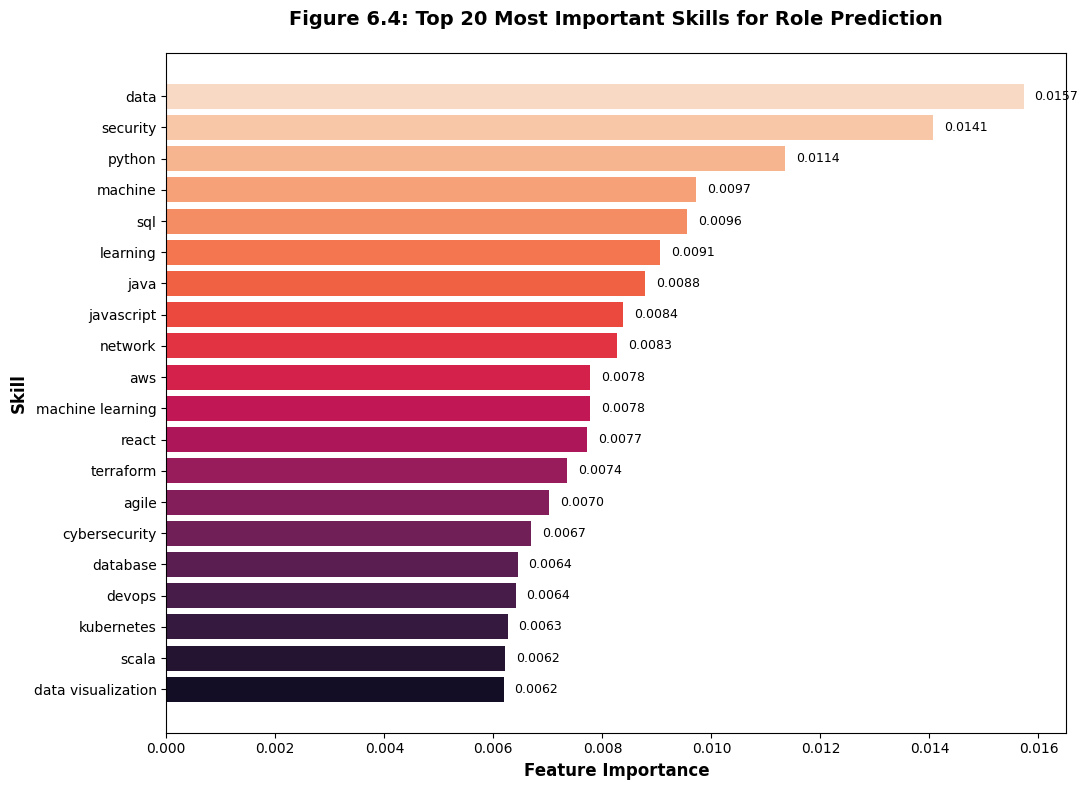

Chart 4 saved!


In [8]:
# Chart 4: Top 20 Most Important Skills (Features)
feature_names = tfidf.get_feature_names_out()
importances = rf_model.feature_importances_

# Get top 20
top_n = 20
top_idx = np.argsort(importances)[-top_n:]
top_importances = importances[top_idx]
top_features = [feature_names[i] for i in top_idx]

plt.figure(figsize=(11, 8))
colors = sns.color_palette("rocket", top_n)
bars = plt.barh(range(top_n), top_importances, color=colors)
plt.yticks(range(top_n), top_features)
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.ylabel('Skill', fontsize=12, fontweight='bold')
plt.title('Figure 6.4: Top 20 Most Important Skills for Role Prediction',
          fontsize=14, fontweight='bold', pad=20)

for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.0002, bar.get_y() + bar.get_height()/2.,
             f'{width:.4f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart4_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")